**Оглавление**<a id='toc0_'></a>    
- [Линейные модели](#toc1_)    
- [Линейная регрессия](#toc2_)    
  - [Постановка задачи](#toc2_1_)    
    - [Введение](#toc2_1_1_)    
    - [Функция потерь](#toc2_1_2_)    
    - [Минимизация функции потерь.](#toc2_1_3_)    
  - [Реализация в коде](#toc2_2_)    
    - [Импорт библиотек, описание констант и функций](#toc2_2_1_)    
    - [Реализация аналитического решения](#toc2_2_2_)    
  - [Проблема аналитического решения](#toc2_3_)    
    - [Градиентный спуск](#toc2_3_1_)    
    - [Реализация градиентного спуска](#toc2_3_2_)    
  - [SGD](#toc2_4_)    
  - [Bias–variance tradeoff](#toc2_5_)    
    - [Постановка проблемы](#toc2_5_1_)    
    - [Bias–variance decomposition](#toc2_5_2_)    
    - [Влияние на выбор модели](#toc2_5_3_)    
    - [Одно из решений](#toc2_5_4_)    
  - [Регуляризация](#toc2_6_)    
    - [Постановка проблемы через переобучение модели](#toc2_6_1_)    
    - [Постановка проблемы через мультиколлинеарность признаков](#toc2_6_2_)    
    - [Решение](#toc2_6_3_)    
      - [l1 LASSO регуляризация](#toc2_6_3_1_)    
      - [l2 Ridge регуляризация](#toc2_6_3_2_)    
    - [Дополнительные заметки про регуляризацию.](#toc2_6_4_)    
  - [Масштабирование данных](#toc2_7_)    
    - [Мотивация для масштабирования](#toc2_7_1_)    
    - [Min-Max масштабирование](#toc2_7_2_)    
    - [Стандартизация](#toc2_7_3_)    
    - [Выбор метода масштабирования данных](#toc2_7_4_)    
- [Логистическая регрессия](#toc3_)    
  - [Отличия от регрессии](#toc3_1_)    
  - [Постановка задачи](#toc3_2_)    
    - [Функция потерь](#toc3_2_1_)    
    - [Минимизация функции потерь](#toc3_2_2_)    
  - [Реализация в коде](#toc3_3_)    
    - [Импорт библиотек, описание констант и функций](#toc3_3_1_)    
    - [Реализация логистической регрессии с градиентным спуском и Ridge регуляризацией](#toc3_3_2_)    
- [Приложение](#toc4_)    
  - ["Распремление" поверхности весов из-за мультиколлинеарности признаков](#toc4_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error

from first_hb_3 import LMUtils

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 1337
RANDOM_STATE2 = 0

# <a id='toc1_'></a>[Линейные модели](#toc0_)

## Введение в линейные модели

В данном хэндбуке нас интересуют линейные функции вида:

$$
y = k \cdot x + b
$$

Сформулируем задачу и опишем линейную функцию более подробно. Пусть задан датасет $(X, y)$, состоящий из $N$ объектов, каждый из которых описывается $D$ признаками. Тогда для одного объекта линейная зависимость принимает вид:

$$
y = w_1 x_1 + \dots + w_D x_D + w_0
$$
или в виде суммы
$$
y = \sum_{i=1}^{D} w_i x_i + w_0
$$

# x - жирным без курсива (вова сказал)

### Векторная форма

Для записи в векторной форме определим:

- $x = (x_1, \dots, x_D) \in \mathbb{R}^{1 \times D}$ — вектор-строка признаков объекта,  
- $w = 
\begin{pmatrix}
w_1 \\
\vdots \\
w_D
\end{pmatrix} \in \mathbb{R}^{D \times 1}$ — вектор-столбец весов,  
- а $w_0$ — свободный коэффициент (сдвиг, bias).

Для удобства можно включить свободный коэффициент в общий вектор весов, добавив к вектору признаков фиктивный признак $x_0 = 1$. Тогда:

- Расширенный вектор признаков: $\tilde{x} = (1, x_1, \dots, x_D) \in \mathbb{R}^{1 \times (D+1)}$
- Расширенный вектор весов: $\tilde{w} = 
\begin{pmatrix}
w_0 \\
w_1 \\
\vdots \\
w_D
\end{pmatrix} \in \mathbb{R}^{(D+1) \times 1}$

Тогда линейную модель можно записать в виде:

$$
y = \tilde{x} \tilde{w}
$$

Или, используя обозначение скалярного произведения:

$$
y = \langle \tilde{x}, \tilde{w} \rangle
$$

где $\langle \cdot, \cdot \rangle$ обозначает стандартное скалярное произведение в $\mathbb{R}^{D+1}$.

### Матричная форма

Сначала пара слов про целевую переменную и классификацию с регрессией. Во-первых, целевая переменная в матричной форме это вектор-столбец размерностью $M \times 1$. Во-вторых, задачи классификации и регрессии можно сформулировать как поиск отображения из множества объектов $X$ в множество возможных таргетов $y$. В случае с регрессией, мы отображаем $X$ в множество вещественных чисел $R$, то есть $X \rightarrow y \in \mathbb{R}^{N \times 1}$. В случае же классификации, $X$ отображается в дискретное множество классов: $X \rightarrow y \in \{1, 2, \dots, K\}^{N \times 1}$, де $K$ — количество классов, а каждое значение целевой переменной соответствует метке одного из этих классов.

Тогда, если объединить все объекты в матрицу признаков $X \in \mathbb{R}^{N \times D}$ (каждая строка — это вектор признаков одного объекта), то для всего датасета линейная модель запишется как:

$$
y = X w
$$

Если учитывается свободный член $w_0$, то матрицу признаков расширяют фиктивным столбцом единиц (слева):

- $\tilde{X} = 
\begin{pmatrix}
1 & x_{11} & \dots & x_{1D} \\
1 & x_{21} & \dots & x_{2D} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{N1} & \dots & x_{ND}
\end{pmatrix}
\in \mathbb{R}^{N \times (D+1)}$

И тогда:

$$
y = \tilde{X} \tilde{w}
$$

Далее мы примем сокращенную форму записи без свободного члена за основную и опустим знак $\tilde{ }$ . Так же, внимательный читатель заметит, что строго говоря, в левой части уравнения у нас не может стоять сама целевая переменная, так как из-за описанного ранее наличия шума, мы не можем точно её предсказать, только приблизить. Исправим это упущение, сказав, что произведение признаков на веса называется **предсказание**. 

$$
y_{pred} = X w
$$

Что ж, теперь мы готовы приступить к линейной регрессии.

# <a id='toc2_'></a>[Линейная регрессия](#toc0_)

## <a id='toc2_1_'></a>[Постановка задачи](#toc0_)

### <a id='toc2_1_1_'></a>[Введение](#toc0_)

Напомним, что мы хотим сделать. Наша задача состоит в нахождении оптимальной функции, которая наиболее точно аппроксимирует реальную зависимость между входными переменными и целевой переменной. Например, мы стремимся найти функцию, которая связывает характеристики недвижимости с её рыночной стоимостью или параметры кредитной истории с вероятностью одобрения займа. Тогда мы сможем делать предсказания на новых данных, для которых неизвестно значение целевой переменной. Процесс нахождения оптимальной функции называется обучением, а то, насколько функция является "оптимальной" определяется функцией потерь.

### <a id='toc2_1_2_'></a>[Функция потерь](#toc0_)

Функция потерь оценивает, насколько сильно расходится вектор реальных значений $y$ и вектор предсказаний $y_{pred}$. Так как в нашей задаче вектора живут в одном пространстве, то в качестве функции потерь можно выбрать расстояние между векторами или **L2-норму** разницы векторов (Евклидово расстояние):

$$
\begin{aligned}
L(y_{pred}, y) &= ||y_{pred} - y||_2
\end{aligned}
$$

Однако такая функция ошибки не учитывает размер выборок, поэтому модифицируем её множителем $1/n$, возведём в квадрат и получим **среднеквадратическое отклонение** или **MSE**:

$$
\begin{aligned}
L(y_{pred}, y) &= \frac{1}{n}||y_{pred} - y||^2_2
\end{aligned}
$$

С раскрытием нормы в виде суммы:

$$
L(y_{\text{pred}}, y) = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{pred}}^{(i)} - y^{(i)})^2
$$

Внимательный читатель скажет: подождите, при чём тут квадрат? Можем не возводить и взять **L1-норму** (манхэттенская норма), тогда получим **среднюю абсолютную ошибку** или **MAE**:

$$
\begin{aligned}
L(y_{pred}, y) &= \frac{1}{n}||y_{pred} - y||_1
\end{aligned}
$$

С раскрытием нормы в виде суммы:

$$
L(y_{\text{pred}}, y) = \frac{1}{n} \sum_{i=1}^{n} |y_{\text{pred}}^{(i)} - y^{(i)}|
$$

"Стоп-стоп, почему теперь L1-норма? А как выбрать правильную?". Что ж, давайте разбираться. Самое лучшее объяснение, что я находил: через вероятностный подход.

### <a id='toc2_1_2_'></a>[Функция потерь. Вероятностный подход](#toc0_)

https://www.youtube.com/watch?app=desktop&v=q7seckj1hwM https://education.yandex.ru/handbook/ml/article/veroyatnostnyj-podhod-v-ml

Мы ранее говорили, что существует идеальная функция, описывающая интересующую нас связь между признаками и целевой переменной, и мы хотим найти приближение этой функции с некоторой ошибкой. И ошибка характеризуется функцией потерь. Так давайте выбирать функцию потерь, исходя из свойств ошибки. Предположим, что 1. наша ошибка не зависима от данных и 2. описывается гауссовским шумом $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. Проиллюстрируем это.

In [2]:
lmutils = LMUtils(RANDOM_STATE)

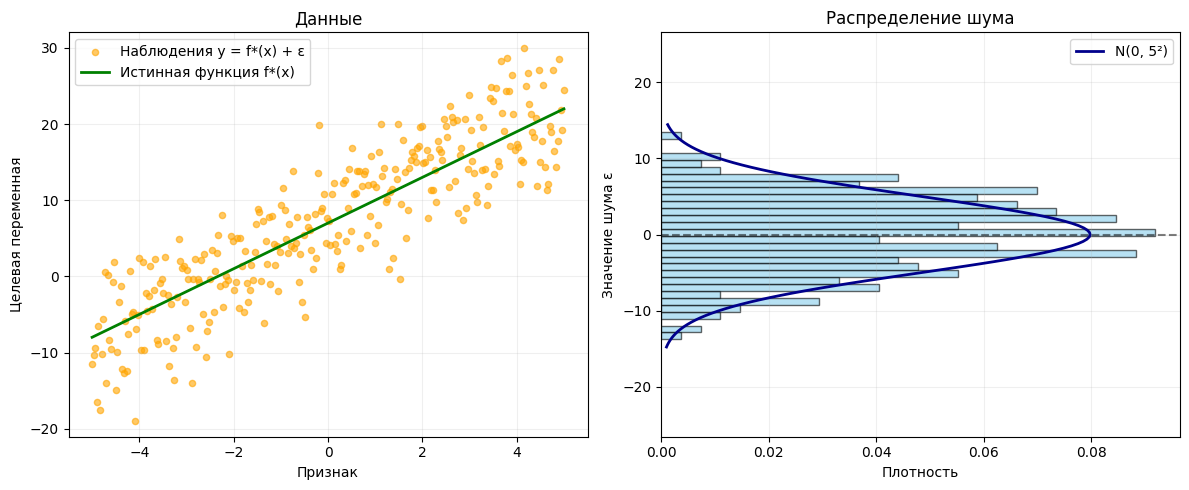

In [3]:
lmutils.plot_linear_data_complete()

# *Почему MLE — это не байесовский подход*

- В MLE моделируется только *условное распределение ( p(y mid X, w) )*, но не вводится предположение о распределении самих параметров $w$.
- В логарифме правдоподобия ты максимизируешь выражение только по $w$ — тебе важно только найти такие параметры, при которых наблюдаемые данные наиболее вероятны.
- Байесианец бы к этому добавил prior $p(w)$ — если его нет, значит это не байесовский вывод.

В реальности, шум может зависеть от целевой переменной, и иметь любое распределение. Например, в задачах прогнозирования цен на недвижимость шум может быть *гетероскедастичным* — дисперсия ошибок для дорогих объектов может быть выше, чем для дешевых. В задачах классификации ошибки часто имеют биномиальное или категориальное распределение, а не гауссовское. В задачах подсчета событий с дискретным таргетом (например, количество клиентов в магазине) ошибки могут следовать распределению Пуассона. Тем не менее, предположение о гауссовском шуме является хорошей отправной точкой, поскольку:
1. *Центральная предельная теорема*: если ошибка является суммой многих независимых случайных факторов, она будет приближенно нормально распределена.
2. *Математическая удобность*: нормальное распределение имеет хорошие аналитические свойства.
3. *Робастность*: многие методы, основанные на предположении нормальности, работают разумно даже при нарушении этого предположения.

Теперь мы можем переформулировать  в условное распределение 

Теперь мы можем переформулировать модель
$$
y = \hat{f}_{w}(x) + \epsilon
$$
# зачем почему и как
в терминах условного распределения 
$$
p(y \mid X, w)
$$
# зачем почему и как
задающего вероятность наблюдать значение $y$ при заданных входных данных $x$ и параметрах модели $w$. Тогда, используя **метод максимального правдоподобия** сведём нашу задачу к
$$
w^* = \arg\max_{w} p(y \mid X, w)
$$
Величина $p(y \mid X, w)$ называется функцией правдоподобия (likelihood). Если мы считаем, что все объекты независимы, то функция правдоподобия распадается в произведение:
$$
p(y \mid X, w) = \prod_{i=1}^{n} p(y_i \mid x_i, w)
$$
С умножением мы не хотим работать, при этом в нашем случае мы максимизируем. Тогда мы можем взять логарифм выражения, поскольку логарифм — монотонная функция, максимум логарифма достигается в той же точке, что и максимум самого выражения. А логарифм разложит произведение на сумму

$$
\log p(y \mid X, w) = \sum_{i=1}^{n} \log p(y_i \mid x_i, w)
$$


$$
p(y_i \mid \langle x_i, w \rangle) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - \langle x_i, w \rangle)^2}{2\sigma^2} \right)
$$

$$
l(y \mid X, w) = \sum_{i=1}^{N} \left( -\log \left( \sqrt{2\pi\sigma^2} \right) - \frac{(y_i - \langle w, x_i \rangle)^2}{2\sigma^2} \right)
$$

Поскольку постоянные множители не зависят от параметров \( w \), их можно отбросить. В результате максимизация логарифма правдоподобия сводится к минимизации следующей суммы:

$$
\sum_{i=1}^{N} (y_i - \langle w, x_i \rangle)^2 = \text{MSE}
$$



Рассмотрим теперь случай, когда ошибки $ \varepsilon_i $ распределены по закону Лапласа:

$$
p(y_i \mid \langle x_i, w \rangle) = \frac{1}{2b} \exp\left( -\frac{|y_i - \langle x_i, w \rangle|}{b} \right)
$$

Тогда логарифмическая функция правдоподобия запишется как

$$
\log p(y \mid X, w) = \sum_{i=1}^n \left( -\log(2b) - \frac{|y_i - \langle x_i, w \rangle|}{b} \right)
$$

Поскольку постоянные слагаемые не зависят от параметров $$ w $$ их можно отбросить. Максимизация логарифма правдоподобия сводится к минимизации суммы абсолютных отклонений:

$$
\sum_{i=1}^n |y_i - \langle x_i, w \rangle| = \text{MAE}
$$

что соответствует функции потерь MAE.

Таким образом выбор функции потерь — это в некотором смысле то же самое, что выбор распределения шума. Для закрепления интуиции происходящего покажем графики самих распределений.

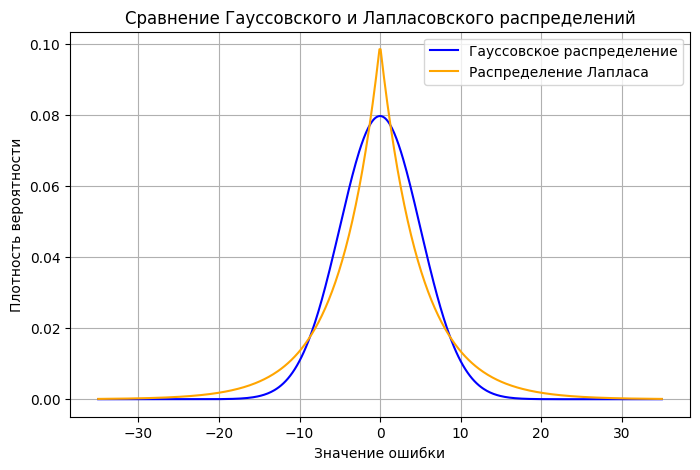

In [4]:
lmutils.compare_gaussian_laplace()

# это же неверно, не данные а шум - какой? ошибка? 

Видно, что у распределения "Лапласа более тяжёлые хвосты", этому распределению могут подчиняться данные, в которых имеются выбросы. Другими словами, если модель с оптимизацией MSE будет пытаться подстроить веса функции под выбросы, чтобы попытаться их описать и перевести в категорию "нормальных значений", то модель с MAE проще отнесётся к выбросам и не будет подгонять w.

А что значит "модель будет пытаться подстроить веса..."? Теперь мы готовы ответить на этот вопрос и перейти к обучению модели, которое работает за счёт минимизации функции потерь.

*2. Не про распределение $y$, а про шум*

Это не то же самое, что распределение исходных $y$!  
Важно: $y$ — это $f(x) +$ шум, и для выбора лосса важно именно, каким распределением обладает *ошибка* модели на каждом $x$ (то есть шум), а не просто весь массив $y$.

- *Пример:* $y$ может быть распределён, как угодно (например, очень ненормально), но если при фиксированном $x$ ошибки модели — гауссовские, тогда MSE оптимален.
- Вы не обязаны знать точное распределение ошибки — это не мешает использовать MSE, MAE, но важно понимать, какой лосс даёт какую статистическую интерпретацию!

---
*3. На практике*

- Мы почти никогда не знаем точное распределение шума $varepsilon$.
- Но если:
    - Много выбросов — MSE сильно штрафует и даёт нестойкие оценки: тогда лучше MAE.
    - Если ошибки маленькие и шум симметричный — MSE быстрее сходится и агрегирует дисперсию.

---
*4. Конкретное утверждение*

> “МSE стоит выбирать, если шум имеет нормальное распределение, а MAE — если лапласово”

Это *корректно*, но речь идёт именно о распределении шума (остатков), а не $y$ в целом.

---
*Итог*

- Лосс-функция (MSE, MAE и др.) выбирается согласно предположениям о *распределении ошибок модели*.
- Не имеет прямого отношения к “форме” всего распределения $y$.
- Лосс определяет, какую характеристику распределения ошибок ваша модель минимизирует (MSE — среднеквадратичное, MAE — медиану ошибки по модулю).
- В реальных задачах выбор часто делается эмпирически (устойчивость, выбросы) кроме теоретических соображений.

# ннада?


Особенность MSE в том, что она является *функционалом* - получает на вход функцию, а на выходе выдаёт число, которое мы хотим **минимизировать**. Такая постановка функции потерь аналогична [**методу наименьших квадратов**](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BD%D0%B0%D0%B8%D0%BC%D0%B5%D0%BD%D1%8C%D1%88%D0%B8%D1%85_%D0%BA%D0%B2%D0%B0%D0%B4%D1%80%D0%B0%D1%82%D0%BE%D0%B2), что в условиях [теоремы Гаусса-Маркова](https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%93%D0%B0%D1%83%D1%81%D1%81%D0%B0_%E2%80%94_%D0%9C%D0%B0%D1%80%D0%BA%D0%BE%D0%B2%D0%B0) является оптимальным подходом. Так же стоит отметить, что минимизация среднеквадратичной ошибки это то же самое, что и *максимизация правдоподобия данных*.

Определив функцию потерь, теперь нужно понять, как её минимизировать.

### <a id='toc2_1_3_'></a>[Минимизация функции потерь.](#toc0_)

Напомним, что мы хотим найти такие веса $w^*$, при которых функция ошибки минимальна:

$$
w^* = \arg\min_{w} \mathcal{L}(w)
$$

Рассмотрим MSE. Чтобы минимизировать эту функцию, мы воспользуемся необходимым условием минимума: в точке минимума градиент функции должен равняться нулю. Найдём градиент функции потерь по параметру $w$ и приравняем его к нулю:

$$
\frac{\partial{L}}{\partial{w}} = 0
$$

Для этого сначала раскроем функцию потерь:

$$
\begin{aligned}
&L(y_{pred}, y) = \frac{1}{n} ||y_{pred} - y||^2_2 = \\ 
&= \frac{1}{n}||Xw - y||^2_2 = \\
&= \frac{1}{n}(Xw - y)^T(Xw - y) = \\
&= \frac{1}{n}( w^T X^TXw - y^TXw - w^T X^Ty  + Y^Ty) =  \\ 
&=\frac{1}{n}(w^TX^TXw - 2y^TXw + Y^Ty),
\end{aligned}
$$
используя следующие свойства:
$$
w^TB^TA = A^TBw
$$
$$
||x||^2_2 = (\sqrt{\langle x, x\rangle})^2 = x^Tx
$$
$$
(AB)^T = B^T A^T
$$

Теперь мы можем выразить градиент, используя [свойства получения производных матриц](https://en.wikipedia.org/wiki/Matrix_calculus#Identities), подробнее можно [почитать здесь](https://habr.com/ru/articles/479398/):

$$
\begin{aligned}
\frac{\partial{L}}{\partial{w}} = \frac{\partial{}}{\partial{w}} \frac{1}{n}(w^TX^TXw - 2y^TXw + y^Ty) = \frac{2}{n}(X^TXw - X^Ty) 
\end{aligned}
$$

Или в краткой форме

$$
\begin{aligned}
\frac{\partial{L}}{\partial{w}} = \frac{2}{n}X^T(y_{pred} - y) \,\, \in \mathbb{R}^{m \times 1}
\end{aligned}
$$

Приравняем его к нулю и выразим $w$:

$$
\frac{2}{n}(X^TXw - X^Ty) = 0
$$
$$
X^TXw = X^Ty
$$
$$
w = (X^TX)^{-1} X^Ty
$$

Мы вывели аналитическое решение задачи линейной регрессии. Реализуем это решение, но сначала импортируем библиотеки, опишем константы и функции.

## <a id='toc2_2_'></a>[Реализация в коде](#toc0_)

### <a id='toc2_2_2_'></a>[Реализация аналитического решения](#toc0_)

Создадим класс `MyLinearRegression`, в котором опишем методы обучения, предсказания и получения матрицы весов.

In [5]:
class MyLinearRegression:
    def __init__(self):
        """Инициализация модели без параметров."""
        self.w = None

    def fit(self, X, y):
        """
        Обучение линейной регрессии с добавлением свободного члена.
        Решается через нормальное уравнение.
        """
        n_samples = X.shape[0]
        X_bias = np.hstack([X, np.ones((n_samples, 1))])
        self.w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
        return self

    def predict(self, X):
        """
        Предсказание значений по входным данным X.
        """
        if self.w is None:
            raise ValueError("Модель не обучена. Сначала вызовите .fit().")

        n_samples = X.shape[0]
        X_bias = np.hstack([X, np.ones((n_samples, 1))])
        return X_bias @ self.w

    def get_weights(self):
        """Возвращает веса модели (включая bias)."""
        return self.w

Для обучения и проверки модели сгенерируем один признак, равномерно распределённый на отрезке, и на его основе сформируем целевую переменную: умножим признак на $3$, прибавим 
$7$ и добавим нормально распределённый шум. Эти значения $(3$ и $7)$ являются истинными коэффициентами, которые мы хотим восстановить с помощью модели — они и должны появиться в итоговом векторе весов $w$.

In [6]:
X, y, y_true, _ = lmutils.generate_linear_data(n_points=100)

model_analytic = MyLinearRegression()
model_analytic.fit(X, y);
pred_analytic = model_analytic.predict(X)

Построим графики объектов, реальной зависимости и предсказанной.

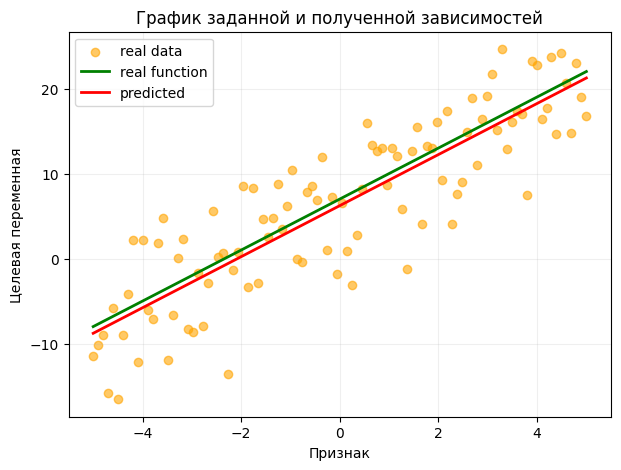

In [7]:
lmutils.plot_predictions(X, y, pred_analytic, y_true)

In [8]:
lmutils.results_metrics_weights(model_analytic, X, y, pred_analytic)

Веса модели: [3.0029, 6.2269]
MSE:  25.6026


Мы получили довольно точное приближение. Однако в таком виде линейная регрессия используется редко, потому что у него имеются недостатки.

## <a id='toc2_3_'></a>[Проблема аналитического решения](#toc0_)

Одна из основных проблем аналитического подхода к линейной регрессии заключается в необходимости обращения матрицы. Это [вычислительно дорого](https://stats.stackexchange.com/questions/278755/why-use-gradient-descent-for-linear-regression-when-a-closed-form-math-solution), особенно если мы работаем с большими датасетами, где число объектов может достигать миллионов.

Вычислительная сложность аналитического решения:

$$
w = (X^T X)^{-1} X^T y
$$

составляет:

$$
\mathcal{O}(D^2 N + D^3)
$$

где:
- $N$ — число объектов в выборке (строк матрицы $X$)
- $D$ — количество признаков (столбцов матрицы $X$)

🔹 Слагаемое $\mathcal{O}(D^2 N)$ — это стоимость перемножения матриц $X^T X$ и $X^T y$  
🔹 Слагаемое $\mathcal{O}(D^3)$ — это стоимость обращения матрицы $X^T X$

Обращение матрицы и явное вычисление формулы стоит использовать с осторожностью. Неэффективно сначала считать $(X^T X)^{-1}$, а затем умножать на $X^T y$. Лучше сначала вычислить $X^T y$, а затем результат умножить на уже обращённую матрицу. Это позволяет сократить вычисления и не хранить всю матрицу $(X^T X)^{-1} X^T$ в памяти.

Кроме того, матрица $(X^T X)^{-1}$ может быть [вырождена или плохо обусловлена](https://alexanderdyakonov.wordpress.com/2019/10/31/%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F-%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F/), особенно если признаки в матрице $X$ линейно зависимы или скоррелированы.  Это приводит к тому, что решение становится нестабильным: веса $w$ могут сильно изменяться даже при незначительных колебаниях входных данных или наличии шума, что, в свою очередь, делает модель неустойчивой и плохо обобщающей, а полученные коэффициенты — неадекватными.

Поэтому, вместо аналитического подхода часто используют **метод градиентного спуска** — итеративную процедуру оптимизации, которая:
- лучше масштабируется на большие данные,
- более устойчива к вырожденности матрицы признаков,
- не требует явного обращения матрицы.

## <a id='toc2_3_1_'></a>[Градиентный спуск](#toc0_)

Градиентный спуск — это численный метод нахождения локального минимума выпуклой функции за счёт движения вдоль направления, противоположного градиенту. Антиградиент указывает направление наискорейшего убывания функции потерь. Этапы градиентного спуска:

1. **Вычисление градиента функции потерь** по весам $w$.  
   В случае квадратичной функции потерь (MSE) градиент имеет вид:

   $$
   \frac{\partial L}{\partial w} = \frac{2}{n} X^T(Xw - y)
   $$

   Это можно также записать в виде суммы:

   $$
   \frac{\partial L}{\partial w} = \frac{2}{n} \sum_{i=1}^n x_i^T (x_i w - y_i)
   $$

   где $x_i$ — $i$-я строка матрицы признаков $X$, $y_i$ — соответствующее значение целевой переменной.

2. **Обновление весов** в направлении антиградиента с шагом обучения $\alpha$ (learning rate):

   $$
   w = w - \alpha \frac{\partial L}{\partial w}
   $$

3. **Повторение шагов** 1 и 2 до тех пор, пока:
   - изменение функции потерь становится пренебрежимо малым,
   - либо достигнуто максимальное число итераций.

Таким образом, градиентный спуск позволяет последовательно улучшать параметры модели, минимизируя ошибку на обучающей выборке.

Общие замечания:
* Поскольку задача выпуклая, выбор начальной точки влияет на скорость сходимости, но не настолько сильно, чтобы на практике нельзя было стартовать всегда из нуля или из любой другой приятной вам точки;
* Число обусловленности матрицы существенно влияет на скорость сходимости градиентного спуска: чем более вытянуты эллипсоиды уровня функции потерь, тем хуже;
* Темп обучения тоже сильно влияет на поведение градиентного спуска; вообще говоря, он является гиперпараметром алгоритма, и его, возможно, придётся подбирать отдельно. Другими гиперпараметрами являются максимальное число итераций и/или порог ошибки, при преодолении которого останавливается обучение.
 
Вычислительная сложность градиентного спуска – $O(NDS)$, где, как и выше, $N$ – длина выборки, $D$ – число признаков у одного объекта, $S$ - число иттераций.

### <a id='toc2_3_2_'></a>[Реализация градиентного спуска](#toc0_)

Класс `MyGradientLinearRegression` будет аналогичен предыдущему, с добавлением приватных методов `_calc_gradient` для вычисления градиента и `_loss` для вычисления ошибки. Так же добавим метод `get_losses` и `get_weights` для получения ошибок и весов.
Зафиксруем `random_state` при инициализации, так как мы не планируем работать с этим параметром.

In [9]:
class MyGradientLinearRegression:
    def __init__(self, lr=0.01, max_iter=100, random_state=RANDOM_STATE):
        """
        Инициализация модели градиентного спуска.
        lr: скорость обучения
        max_iter: число итераций
        """
        self.lr = lr
        self.max_iter = max_iter
        self.random_state = random_state
        self.w = None
        self.losses = []
        self.weights_history = []

    def fit(self, X, y):
        """
        Обучение модели линейной регрессии с помощью градиентного спуска.
        """
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        X_bias = np.hstack([X, np.ones((n_samples, 1))])

        self.w = np.random.randn(n_features + 1)

        for _ in range(self.max_iter):
            y_pred = X_bias @ self.w
            grad = self._compute_gradient(X_bias, y, y_pred)
            self.w -= self.lr * grad

            self.weights_history.append(self.w.copy())
            self.losses.append(self._compute_loss(y, y_pred))

        return self

    def _compute_gradient(self, X_bias, y, y_pred):
        """
        Вычисление градиента функции потерь MSE.
        """
        n = X_bias.shape[0]
        return (2 / n) * X_bias.T @ (y_pred - y)

    def _compute_loss(self, y, y_pred):
        """
        Вычисление значения функции потерь (MSE).
        """
        return mean_squared_error(y, y_pred)

    def predict(self, X):
        """
        Предсказание значений по входным данным X.
        """
        if self.w is None:
            raise ValueError("Модель не обучена. Сначала вызовите .fit().")

        n_samples = X.shape[0]
        X_bias = np.hstack([X, np.ones((n_samples, 1))])
        return X_bias @ self.w

    def get_weights(self, history=False):
        """
        Возвращает веса модели.
        Если history=True — возвращает историю весов за все итерации.
        """
        return np.array(self.weights_history) if history else self.w

    def get_losses(self):
        """
        Возвращает историю значений функции потерь.
        """
        return np.array(self.losses)

Повторим эксперимент, проведённый для аналитического решения и добавим визуализацию изменения функции потерь и весов в процессе обучения.

In [10]:
X, y, y_true, _ = lmutils.generate_linear_data(n_points=100)

model_gradient = MyGradientLinearRegression(lr=0.02)
model_gradient.fit(X, y);
pred_gradient = model_gradient.predict(X)

In [11]:
lmutils.results_metrics_weights(model_gradient, X, y, pred_gradient)

Веса модели: [3.0029, 6.1136]
MSE:  25.6154


In [12]:
losses_history_gradient = model_gradient.get_losses()
weights_history_gradient = model_gradient.get_weights(history=True)

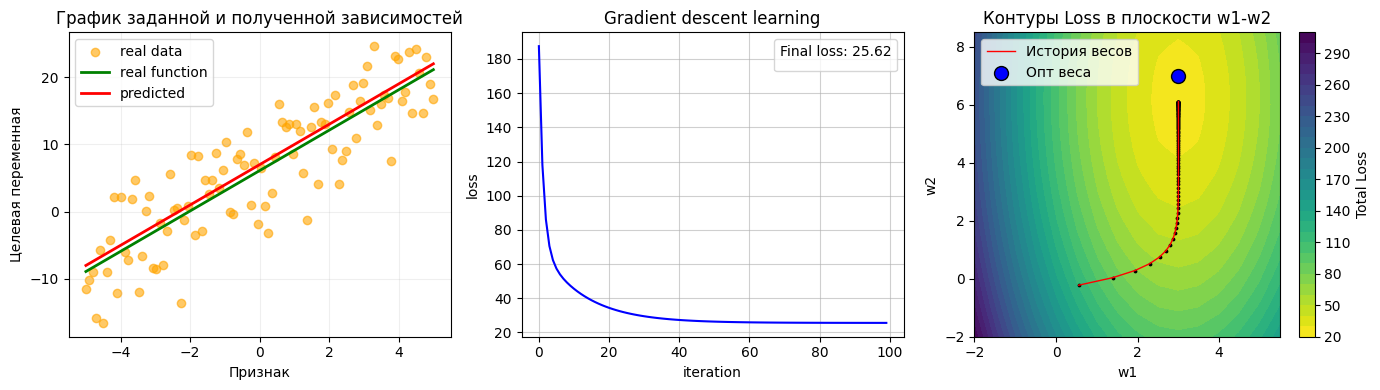

In [13]:
lmutils.plot_reg_results(X, y, pred_gradient, y_true, losses_history_gradient, weights_history_gradient)

Тоже отличный результат. Однако на каждой иттерации нам нужно загружать в память и обработатывать сразу всю выборку. Возникает идея заменить градиент его оценкой на подвыборке.

### <a id='toc2_4_'></a>[SGD](#toc0_)

<img src="https://yastatic.net/s3/ml-handbook/admin/1_7_4b8031112e.png" width="800" height="400">

Источник: [Хэндбук Яндекса — 2.1. Линейные модели](https://education.yandex.ru/handbook/ml/article/linear-models)


Стохастический градиентный спуск - стохастическая аппроксимация метода градиентного спуска на случайной подвыборке. При таком подходе нам не нужно хранить всю выборку в памяти, градиенты считаются быстрее, веса обновляются чаще. Поиск становится чуть более "шумным", так как выбросы и шумы вносят больше влияния из-за малого размера данных, но в конечно итоге мы всё-равно придём в область минимума. Градиент считается по выборке, поэтому формула:

$$
\nabla_w L(w, X, y) \approx \frac{1}{B} \sum_{t=1}^{B} \nabla_w L(w, x_{i_t}, y_{i_t})
$$

где:
- $B$ — размер батча,
- $(x_{i_t}, y_{i_t})$ — случайно выбранные объекты из обучающей выборки.

Мы делим сумму на $B$, чтобы получить *средний градиент по батчу*, а не просто сумму градиентов. Это делает шаг обучения стабильным и сопоставимым по масштабу с градиентом, вычисленным на всей выборке. Такое усреднение позволяет корректно применять шаг обучения $\alpha$ вне зависимости от размера батча.


Для реализации `SGD` мы будем случано выбирать `batch_size` элементов из тренировочной выборки. Однако наиболее оптимальный подход - перемешиване выборки изначально, и далее получение индексов подвыборки линейным проходом, но чтобы его реализовать, понадобится вносить много изменений в класс `MyGradientLinearRegression`.

Сложность по времени – $O(NDE)$, где - $E$ - количество эпох в случае с линейным проходом по индексам.

Для демонстрации выкрутим `SGD` на максимум - сделаем размер выборки $5$, а `lr` уменьшим до $0.01$, иначе будет очень шумно. Сходимость снизится, поэтому увеличим количество иттераций `max_iter`, чтобы дойти до минимума.

In [14]:
class MySGDLinearRegression(MyGradientLinearRegression):
    def __init__(self, batch_size=10, **kwargs):
        """
        Инициализация модели SGD-регрессии.

        batch_size: размер случайной подвыборки (batch)
        Остальные параметры передаются в MyGradientLinearRegression
        """
        super().__init__(**kwargs)
        self.batch_size = batch_size

    def _compute_gradient(self, X_bias, y, y_pred):
        """
        Вычисление градиента по случайной подвыборке (batch).
        """
        n_total = X_bias.shape[0]
        indices = np.random.choice(n_total, size=self.batch_size, replace=False)
        X_batch = X_bias[indices]
        y_batch = y[indices]
        y_pred_batch = y_pred[indices]

        return (2 / self.batch_size) * X_batch.T @ (y_pred_batch - y_batch)

In [15]:
model_SGD = MySGDLinearRegression(batch_size=5, lr=0.01, max_iter=300)
model_SGD.fit(X, y);
pred_SGD = model_SGD.predict(X)

In [16]:
lmutils.results_metrics_weights(model_SGD, X, y, pred_SGD)

Веса модели: [2.8197, 5.9518]
MSE:  25.9636


In [17]:
losses_history_SGD = model_SGD.get_losses()
weights_history_SGD = model_SGD.get_weights(history=True)

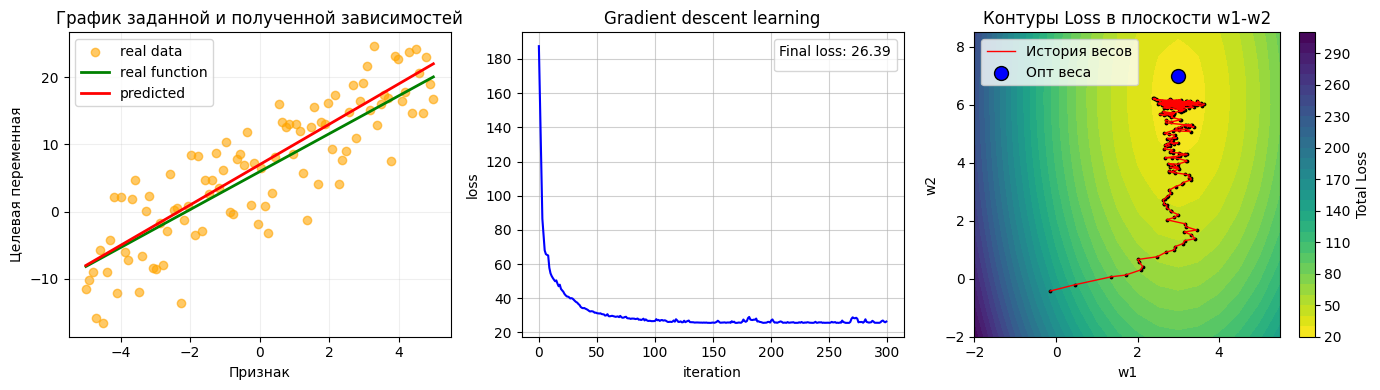

In [18]:
lmutils.plot_reg_results(X, y, pred_SGD, y_true, losses_history_SGD, weights_history_SGD)

Видно, что сходимость `SGD` хуже по сравнению с обычным градиентным спуском: она более "шумная", требует больше итераций для достижения минимума и чувствительна к выбору гиперпараметров, особенно `batch_size` и `learning rate`. С одной стороны, `SGD` позволяет существенно экономить ресурсы — как вычислительные, так и по объёму памяти, особенно на больших датасетах. С другой — делает процесс обучения менее стабильным.

Далее рассмотрим несколько проблем, свойственных линейным (и не только) моделям.

## <a id='toc2_7_'></a>[Масштабирование данных](#toc0_)

### <a id='toc2_7_1_'></a>[Мотивация для масштабирования](#toc0_)

Мы уже затрагивали эту тему ранее и отмечали, что *learning_rate* нужен для согласования порядка весов и градиента функции потерь. При этом если наши признаки имеют разные масштабы, то и веса, и градиент для них подбираются с разными масштабами, что приводит к неравномерному перемещению по поверхности функции потерь, а правильнее сказать, что сама поверхность функции потерь вытягивается из-за разного масштаба признаков -> весов и перемещение градиента по ней не оптимально (что можно было бы исправить разным *learning_rate* для каждого признака, но это уже перебор, а если признаков 1000?). Это видно даже на наших графиках. Отобразим ещё раз, сконцентрировавшись на весах.

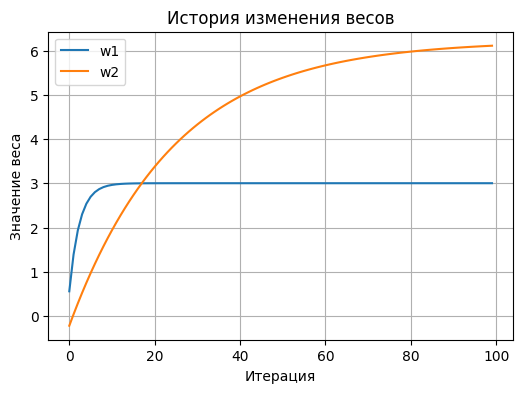

In [19]:
lmutils.plot_weights_history(weights_history_gradient)

При этом если отличия признаки отличаются значительно (например в $10^4$ раз), то мы можем вовсе не прийти к минимуму функции потерь, либо это займёт больше времени. Поэтому было бы неплохо, чтобы признаки имели одинаковый масштаб, чтобы и их веса были близки. Это приведёт ещё и к улучшению **интерпретируемости** модели - для признаков одного масштаба верно, что чем больше вес признака, тем более он важен для получения предсказания, однако смысл самих коэффициентыов не будет так очевиден. Рассмотрим на примере выдуманной связи роста и возраста с размером ноги. Если мы масштабируем рост и возраст и вместо 180см и 25 лет получаем 0.9 и 0.7, то соотношение к целевой переменной вовсе не обязательно сохранится. Условно первая модель могла иметь веса $180*0.2 + 25*0.4 = 46$, то модель на масштабированных признаках может выглядеть $0.9*45 + 0.7*8=46$. В первом случае можно интерпретировать связь каждого признака и целевой переменной, зато во втором видно, что первый признак значительно важнее.

Отдельно стоит отметить, что масштабирование (какое именно, рассмотрим позже) признаков необходимо при применении регуляризации ([ссылка 1](https://stats.stackexchange.com/questions/19523/need-for-centering-and-standardizing-data-in-regression) и [ссылка 2](https://stats.stackexchange.com/questions/201909/when-to-normalize-data-in-regression)). Логика такая же, как и с *learning_rate*: для адэкватного штрафа необходимо, чтобы веса имели один масштаб.

Особенно важно масштабирование признаков для алгоритмов [SVM](https://stats.stackexchange.com/questions/65094/why-scaling-is-important-for-the-linear-svm-classification) и [KNN](https://stats.stackexchange.com/questions/287425/why-do-you-need-to-scale-data-in-knn), которые будут рассмотрены в будущем. Эти алгоритмы основаны на вычислении расстояний между точками данных. Если объекты имеют разные масштабы, в расчетных расстояниях могут доминировать объекты с более крупными масштабами, что приведет к неточным результатам. Масштабирование объектов может решить эту проблему и обеспечить расчет расстояний на основе фактических отношений между точками данных.

Что бы понять, как масштабировать данные, рассмотрим два самых часто используемых метода: **Min-Max** и **стандартизация**. Но сначала импортируем библиотеки и опишем функции.

In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
def scaler_example(scaler):
    data_train = [[-2, 2], [-0.5, 6], [0, 10], [1, 18]]
    data_test = [[-4 , 20], [1, 5]]
    
    data_train_scaled = scaler.fit_transform(data_train)
    data_test_scaled = scaler.transform(data_test)

    print('data_train_scaled')
    print(data_train_scaled)
    print()
    print('data_test_scaled')
    print(data_test_scaled)

In [22]:
def plot_distribution(data, mean, std, title, ax):
    sns.histplot(data, bins=50, ax=ax, kde=True, legend=False)
    ax.set_title(title)

    ax.legend([
        f'Mean 1: {mean[0]:.2f}',
        f'Std Dev 1: {std[0]:.2f}',
        f'Mean 2: {mean[1]:.2f}',
        f'Std Dev 2: {std[1]:.2f}'
    ], handlelength=0)

In [23]:
def plot_boxplot(data, title, ax):
    sns.boxplot(data=data, ax=ax, orient='h')
    ax.set_title(title)

In [24]:
def data_distribution(scaler):
    original_data = np.random.exponential(size=1000).reshape(-1, 1) - 3
    additional_feature = np.random.normal(loc=2.0, scale=0.2, size=(1000, 1))
    combined_original = np.hstack((original_data, additional_feature))
    
    scaled_data = scaler.fit_transform(combined_original)

    original_mean = np.mean(combined_original, axis=0)
    original_std = np.std(combined_original, axis=0)
    scaled_mean = np.mean(scaled_data, axis=0)
    scaled_std = np.std(scaled_data, axis=0)

    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    plot_distribution(combined_original, original_mean, original_std, "Оригинальные данные", ax1)

    ax2 = fig.add_subplot(gs[0, 1])
    plot_distribution(scaled_data, scaled_mean, scaled_std, "Масштабированные данные", ax2)

    ax3 = fig.add_subplot(gs[1, 0])
    plot_boxplot(combined_original, "Боксплот оригинальных данных", ax3)

    ax4 = fig.add_subplot(gs[1, 1])
    plot_boxplot(scaled_data, "Боксплот масштабированных данных", ax4)
    
    plt.tight_layout()
    plt.show()

### <a id='toc2_7_2_'></a>[Min-Max масштабирование](#toc0_)

[Min-max масштабирование](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) (далее MinMaxScaler) используется для приведения данных в указанных диапазон, обычно $[0,1]$ по формуле:

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

В процессе масштабирования MinMaxScaler, вычитая минимальное значение из каждой точки данных и деля результат на диапазон (максимальное значение минус минимальное значение), значения признака преобразуются в диапазон $[0,1]$. Этот процесс гарантирует, что минимальное значение становится $0$, а максимальное значение — $1$, при этом сохраняются относительные отношения между остальными значениями.

In [25]:
scaler_min_max = MinMaxScaler()

scaler_example(scaler_min_max)

data_train_scaled
[[0.         0.        ]
 [0.5        0.25      ]
 [0.66666667 0.5       ]
 [1.         1.        ]]

data_test_scaled
[[-0.66666667  1.125     ]
 [ 1.          0.1875    ]]


Обратите внимание, скейлер сначала обучается на тренировочной выборке и только потом применяется к тестовой. Это связано с тем, что тестовый набор играет роль новых, не виденных ранее данных, поэтому он не должен быть доступен на этапе обучения. Использование любой информации из тестового набора до или во время обучения может привести к потенциальному искажению оценки производительности. При нормализации тестового набора необходимо применять параметры нормализации, полученные ранее из обучающего набора, в том виде, в каком они есть. Другими словами произойдёт *утечка*. Не следует пересчитывать их на тестовом наборе, поскольку это будет не согласовано с моделью и приведет к неверным предсказаниям. Более подробно [можно почитать здесь](https://stackoverflow.com/questions/49444262/normalize-data-before-or-after-split-of-training-and-testing-data).

Из результатов видно, что если признаки в тестовой выборке имеют значения больше, чем в тренировочной, то после масштабирования они будут вне диапазона $[0,1]$. Это свойственно и StandardScaler. Так же MinMaxScalerx чувствителен к выбросам, так как одно значение, сильно большее, чем все остальные, значительно сократит значения всей выборки.

Посмотрим, как меняется распределение данных при применении MinMaxScaler для данных, полученных из экспоненциального и нормального распределений.

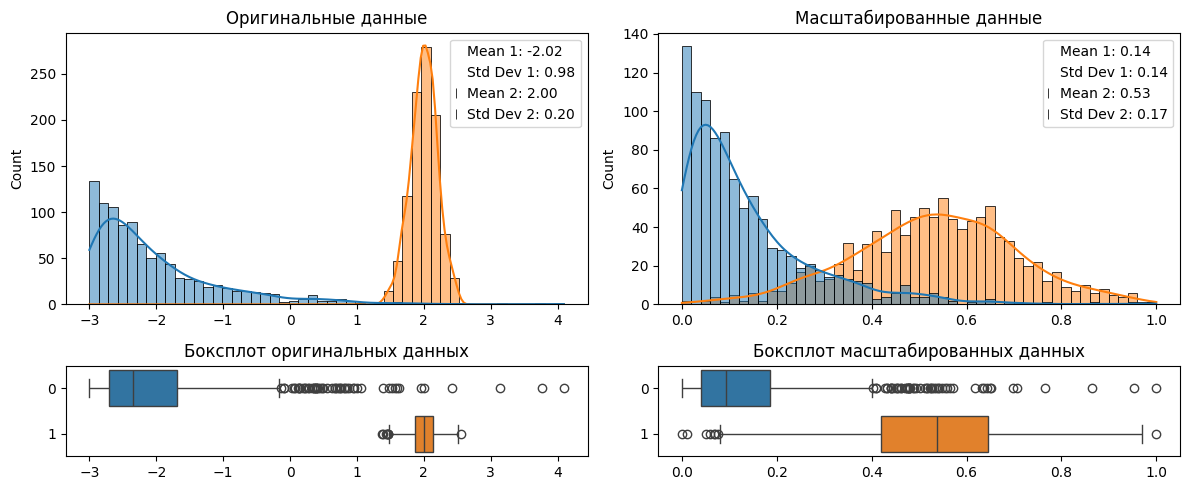

In [26]:
data_distribution(scaler_min_max)

Обе характеристики были масштабированы так, чтобы находиться в диапазоне от 0 до 1, а межквартильные разности (IQR) стали более сопоставимыми по размеру, что иллюстрирует, что характеристики теперь находятся на схожем масштабе.

Теперь рассмотрим второй способ масштабирования данных: **стандартизация**.

### <a id='toc2_7_3_'></a>[Стандартизация](#toc0_)

[Стандартизация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) (далее StandardScaler) приводит признаки к распределению [со средним 0 и стандартным отклонением 1](https://stackoverflow.com/questions/40758562/can-anyone-explain-me-standardscaler). Для этого каждое значение в данных преобразуется следующим образом:.

$$
Z = \frac{x-\mu}{\sigma},
$$
где  
$\mu$ - среднее изначального набора данных,  
$\sigma$ - стандартное отклонение изначального набора данных

Такое преобразование также называется **Z-score normalization**.

In [27]:
scaler_std = StandardScaler()

scaler_example(scaler_std)

data_train_scaled
[[-1.5011107  -1.18321596]
 [-0.11547005 -0.50709255]
 [ 0.34641016  0.16903085]
 [ 1.27017059  1.52127766]]

data_test_scaled
[[-3.34863156  1.85933936]
 [ 1.27017059 -0.6761234 ]]


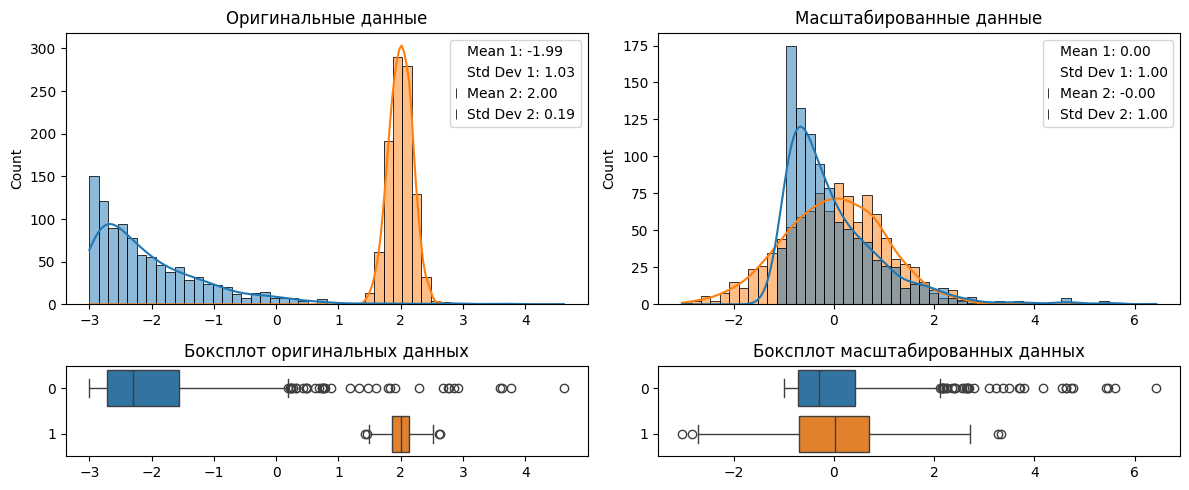

In [28]:
data_distribution(scaler_std)

Обе характеристики после стандартизации имеют нулевое среднее и стандартные отклонения равные $1$, при этом медианы так же близки. Межквартильные разности (IQR) тоже стали сопоставимы.

### <a id='toc2_7_4_'></a>[Выбор метода масштабирования данных](#toc0_)

MinMaxScaler лучше применять, когда данные имеют ограниченный и заранее известный масштаб, например, в обработке изображений значения пикселей обычно находятся в диапазоне от $0$ до $255$. Масштабирование этих значений с использованием MinMaxScaler обеспечивает то, что значения находятся в фиксированном диапазоне и вносят одинаковый вклад в анализ. [Аналогично, при работе с негауссовскими распределениями](https://vitalflux.com/minmaxscaler-standardscaler-python-examples/#:~:text=MinMaxScaler%20is%20useful%20when%20the,contributes%20equally%20to%20the%20analysis.), такими как распределение по степенному закону, можно использовать MinMaxScaler, чтобы гарантировать, что диапазон значений масштабируется между $0$ и $1$.

Так же MinMaxScaler можно применять к данным для обучения алгоритмов, которые не делают предположений о распределении данных, таких как деревьев решений и случайных лесов. Эти алгоритмы не зависят от масштаба признаков, так как они основываются на делении пространства на основе значений признаков, поэтому можно использовать разные методы масштабирования, но нормализация в диапазоне $[0, 1]$ может позволить лучше интерпретировать результаты.

StandardScaler лучше применять к данным, на которых будут обучаться линейные алгоритмы, kNN, k-means, SVM и PCA. Первые используют градиентный спуск, а StandardScaler позволяет привести распределения данных около $0$, что улучшит сходимость, при этом у признаков сохранится разница в масштабах. Плюс линейные модели предполагают, что данные распределены нормально, с чем помогает StandardScaler. Если обобщать kNN, k-means, SVM и PCA, то они используют расстояния, [которые так же лучше масштабировать StandardScaler](https://stackoverflow.com/questions/32108179/linear-regression-normalization-vs-standardization), чтобы сохранить информацию о размахе признаков. При этом StandardScaler лучше подходит для данных, распределённых нормально и более устойчив к выбросам.

В данной тетрадке мы не применяем методы масштабирования данных, потому что изначально подбираем признаки схожих масштабов, плюс некоторые визуализации получаются нагляднее. Теперь можно приступать ко вторму разделу: решению задачи классификации. Это можно делать с помощью **логистической регрессии**.

# <a id='toc3_'></a>[Логистическая регрессия](#toc0_)

Логистическая регрессия является частным случаем *линейного классификатора*. Основная идея линейного классификатора заключается в том, что признаковое пространство может быть разделено гиперплоскостью на два полупространства (для задачи бинарной классификации), в каждом из которых прогнозируется одно из двух значений целевого класса.

## <a id='toc3_1_'></a>[Отличия от регрессии](#toc0_)

Мы можем попробовать предсказывать числа $-1$ и $1$, минимизируя для этого, например, MSE с последующим взятием знака, но ничего хорошего не получится. Во-первых, регрессия почти не штрафует за ошибки на объектах, которые лежат близко к *разделяющей плоскости*, но не с той стороны. Во вторых, ошибкой будет считаться предсказание, например, $5$ вместо $1$, хотя нам-то на самом деле не важно, какой у числа модуль, лишь бы знак был правильным. Если визуализировать такое решение, то проблемы тоже вполне заметны:

<img src="https://yastatic.net/s3/ml-handbook/admin/1_11_0fe41ca811.png" width="500" height="300">

Так же при получении удачной линии регрессии, появление новых данных сместит эту границу, и, как следствие, ничего не добавит, а только ухудшит точность модели:

<img src="https://www.dmitrymakarov.ru/wp-content/uploads/2022/04/new-observation-case.png" width="500" height="250">

## <a id='toc3_2_'></a>[Постановка задачи](#toc0_)

In [29]:
def plot_logloss():
    def L(y):
        return - y * np.log(p) - (1 - y) * np.log(1 - p)
    
    p = np.linspace(0.01, 0.99, 100)
    
    logloss_y0 = L(0)
    logloss_y1 = L(1)
    
    plt.figure(figsize=(7,4))
    plt.plot(p, logloss_y0, label='-log(p) | y=0', color='blue')
    plt.plot(p, logloss_y1, label='-log(1-p) | y=1', color='orange')
    
    plt.title('Логистическая Потеря (Log Loss) для y=0 и y=1')
    plt.xlabel('Предсказанная вероятность p')
    plt.ylabel('Логистическая потеря')
    plt.ylim(0, 5)
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.legend()
    plt.grid()
    plt.show()

In [30]:
def plot_sigmoid():
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    x = np.linspace(-8, 8, 100)
    y = sigmoid(x)
    
    plt.figure(figsize=(7, 4))
    plt.plot(x, y, label='Сигмоида', color='blue')
    plt.title('График функции сигмоида')
    plt.xlabel('x')
    plt.ylabel('σ(x)')
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.xlim(-8, 8)
    plt.ylim(-0.1, 1.1)
    plt.grid()
    plt.show()

Итак, в идеале нам хотелось бы пресдказывать не метки классов, а *вероятности принадлежности объектов к классам*. Проблема состоит в том, что вероятность, по определению, величина от 0 до 1, а простого способа обучить линейную модель так, чтобы это ограничение соблюдалось, нет. Из этой ситуации можно выйти так: научить линейную модель правильно предсказывать какой-то объект, связанный с вероятностью, но с диапазоном значений $(-\infty, \infty)$, и преобразовать ответы модели в вероятность. Таким объектом является **logit** или **log odds** – логарифм отношения вероятности положительного события к отрицательному - $log(\frac{p}{1-p})$. То есть модель предсказывает логит, который в дальнейшем будет трансформирован в вероятность принадлежности к классу:

$$
\langle w, x \rangle = log(\frac{p}{1-p})
$$
$$
e^{\langle w, x \rangle} = \frac{p}{1-p}
$$
$$
p = \frac{1}{1+e^{\langle w, x \rangle}}
$$

Функция в правой части называется **сигмоидой**, она выполняет преобразование $R → [0, 1]$ и обозначается:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

График сигмоиды:

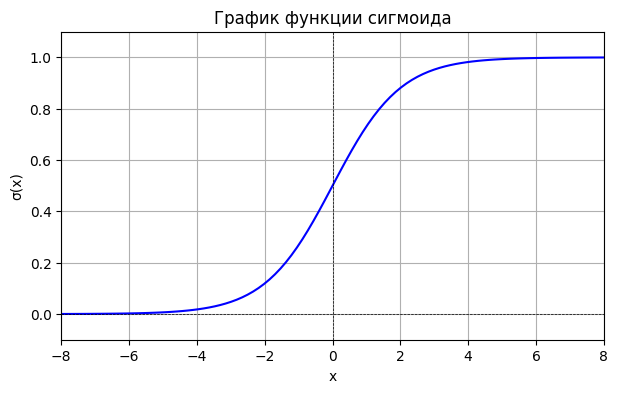

In [31]:
plot_sigmoid()

Таким образом, $p=\sigma({\langle w, x \rangle})$. Как теперь оптимизировать решение? Нужно применить метод *максимума правдоподобия для распределения Бернулли*.

### <a id='toc3_2_1_'></a>[Функция потерь](#toc0_)

Правдоподобие позволяет понять, насколько вероятно получить данные значения таргета $y$ при данных $X$ и весах $w$. Оно имеет вид:

$$
p(y|X, w) = \prod_{i} p(y_i|x_i, w)
$$

и для распределения Бернулли его можно выписать следующим образом:

$$
p(y|X, w) = \prod_{i} p_i^{y_i} (1-p_i)^{1-y_i},
$$

где $p_i$ – это вероятность, посчитанная из ответов модели.

От произведения перейдём к сумме с помощью логарифмирования и подставим формулу для вероятности:

$$
l(w, X, y) = \sum_{i} (y_i log(p_i) + (1-y_i) log (1-p_i)) = \sum_{i} (y_i log(\sigma({\langle w, x \rangle})) + (1-y_i) log (-\sigma({\langle w, x \rangle}))),
$$
так как $\sigma(-z) = 1-\sigma(z)$

В модели логистической регрессии мы не можем использовать MSE. Дело в том, что если мы поместим результат сигмоиды (представляющей собою нелинейную функцию) в MSE, то на выходе получим невыпуклую функцию (non-convex), глобальный минимум которой довольно сложно найти. Вместо MSE мы будем использовать функцию **логистической ошибки**, которую еще называют функцией **бинарной кросс-энтропии** (log loss, binary cross-entropy loss).

Нас интересует $w$, для которого правдоподобие максимально. Чтобы получить **логистическую функцию потерь**, которую мы будем **минимизировать**, умножим его на минус один:

$$
L(w, X, y)  = - \sum_{i} (y_i log(\sigma({\langle w, x \rangle})) + (1-y_i) log (-\sigma({\langle w, x \rangle}))),
$$

Для каждого из классов logloss принимает следующий вид:

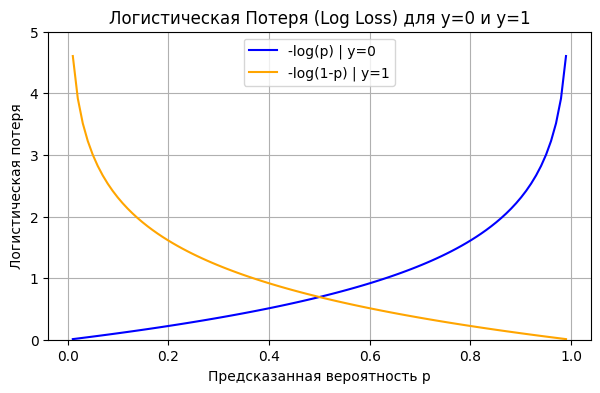

In [32]:
plot_logloss()

Отметим неприятное свойство logloss: если для объекта 1го класса мы предсказываем нулевую вероятность принадлежности к этому классу или, наоборот, для объекта 0го – единичную вероятность принадлежности к классу 1, то ошибка равна бесконечности! Таким образом, грубая ошибка на одном объекте сразу делает алгоритм бесполезным. На практике часто логлосс ограничивают каким-то большим числом (чтобы не связываться с бесконечностями).

Функция потерь определена, теперь посмотрим, как её минимизировать.

### <a id='toc3_2_2_'></a>[Минимизация функции потерь](#toc0_)

В отличие от линейной регрессии, для логистической нет явной формулы решения, поэтому будем использовать градиентный спуск.

Так как
$$
\frac{\partial{log(\sigma(z))}}{\partial{z}} =\sigma(-z) =>  \frac{log(\sigma({\langle w, x_i \rangle})}{\partial{w}} = \sigma(-{\langle w, x_i \rangle})x_i
$$ 
$$
\frac{\partial{L}}{\partial{w}} = - \sum_{i} x_i ( y_i -\sigma({\langle w, x_i \rangle})) = - \sum_{i} x_i ( y_i - p_i)
$$

Или в матричной форме:
$$
\frac{\partial{L}}{\partial{w}} = X^T (p - y)
$$

Перед реализацией в коде стоит отметить, что при очень больших отрицательных или положительных значениях $z$ может возникнуть переполнение памяти. Преодолеть это ограничение и добиться вычислительной устойчивости алгоритма можно с помощью следующего тождества:

$$
\sigma(z) = \frac{1}{1+e^{-z}} = \frac{e^z}{e^{z}+1}
$$

Что интересно, первая часть тождества устойчива при очень больших положительных значениях $z$, при этом вторая стабильна при очень больших отрицательных значениях $z$.

Регуляризация логистической регрессии имеет такой же вид, как и линейной регрессии:

$$
\frac{\partial{L1}}{\partial{w}} = X^T (p - y) + \lambda sign(w)
$$
$$
\frac{\partial{L2}}{\partial{w}} = X^T (p - y) + 2 \lambda w
$$

Теперь у нас есть всё, чтобы реализовать код для логистической регрессии с Ridge регуляризацией.

## <a id='toc3_3_'></a>[Реализация в коде](#toc0_)

### <a id='toc3_3_1_'></a>[Импорт библиотек, описание констант и функций](#toc0_)

In [33]:
from sklearn.datasets import make_blobs

In [34]:
def plot_decision_boundary(ax, clf, X, y):
    colors = ("magenta", "green")
    colored_y = np.zeros(y.size, dtype=str)

    for i, cl in enumerate([0, 1]):
        colored_y[y == cl] = str(colors[i])

    eps = 0.1
    xx, yy = np.meshgrid(np.linspace(np.min(X[:, 0]) - eps, np.max(X[:, 0]) + eps, 500),
                         np.linspace(np.min(X[:, 1]) - eps, np.max(X[:, 1]) + eps, 500))

    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.pcolormesh(xx, yy, Z, cmap=plt.get_cmap('viridis'), shading='auto')

    Z_pred = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_pred = Z_pred.reshape(xx.shape)

    contour = ax.contour(xx, yy, Z_pred, levels=[0.5], linewidths=2, colors='black')

    ax.scatter(X[:, 0], X[:, 1], c=colored_y)
    ax.set_title('Разделяющая плоскость логистической регрессии')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

In [35]:
def plot_equipotentials(X, y, weights_history, range=(-2, 10)):
    fig, ax = plt.subplots(figsize=(7, 5))
    equipotentials_graph(ax, X, y, weights_history, range)
    plt.show() 

In [36]:
def plot_clf_results(model, X, y_real):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    plot_decision_boundary(axes[0], model, X, y_real)
    losses_graph(axes[1], model)
    
    plt.tight_layout()
    plt.show()

### <a id='toc3_3_2_'></a>[Реализация логистической регрессии с градиентным спуском и Ridge регуляризацией](#toc0_)

In [37]:
class MyLogisticRegression():
    def __init__(self, lr=0.01, max_iter=100, C=1.0):
        self.lr = lr
        self.max_iter = max_iter
        self.C = C
        self.random_state = RANDOM_STATE
        self.w = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        
        self.losses = []
        self.weights = []
        n, m = X.shape
        self.w = np.random.randn(m + 1)
        X_train = np.hstack((X, np.ones((n, 1))))

        for _ in range(self.max_iter):
            self.weights.append(np.copy(self.w))
            p_pred = self.predict_proba(X)
            grad = (2/n) * self._calc_gradient(X_train, y, p_pred)

            self.w -= self.lr * grad
            self.losses.append(self._calc_loss(y, p_pred))

        return self

    def predict_proba(self, X):
        n, k = X.shape
        X_ = np.hstack((X, np.ones((n, 1))))
        return np.array([self._stable_sigmoid(value) for value in self._logit(X_, self.w)])

    def predict(self, X, threshold=0.5):
        return self.predict_proba(X) >= threshold

    def get_weights(self, history=False):
        if history:
            return np.array(self.weights)
        else:
            return self.w

    def get_losses(self):
        return self.losses

    def _calc_gradient_L2(self):
        return (2 / self.C) * self.w[:-1]

    def _calc_gradient(self, X_train, y, p_pred):
        grad = np.dot(X_train.T, (p_pred - y))
        grad[:-1] += self._calc_gradient_L2()
        return grad

    def _calc_loss_L2(self, y):
        return (1 / (2 * self.C * len(y))) * np.sum(self.w[:-1] ** 2)

    def _calc_loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        loss = np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        loss += self._calc_loss_L2(y)
        return -loss

    def _logit(self, x, w):
        return np.dot(x, w)

    def _stable_sigmoid(self, z):
        if z >= 0:
            return 1 / (1 + np.exp(-z))
        else:
            return np.exp(z) / (np.exp(z) + 1)

In [38]:
X, y = make_blobs(n_samples=1000, centers=[[-2,0.5],[2,-0.5]], cluster_std=1, random_state=RANDOM_STATE)

Построим два классификатора с `C=100` и `C=0.003`.

In [39]:
CLF_1 = MyLogisticRegression(max_iter=100, lr=0.1, C=100)

CLF_1.fit(X, y);

NameError: name 'losses_graph' is not defined

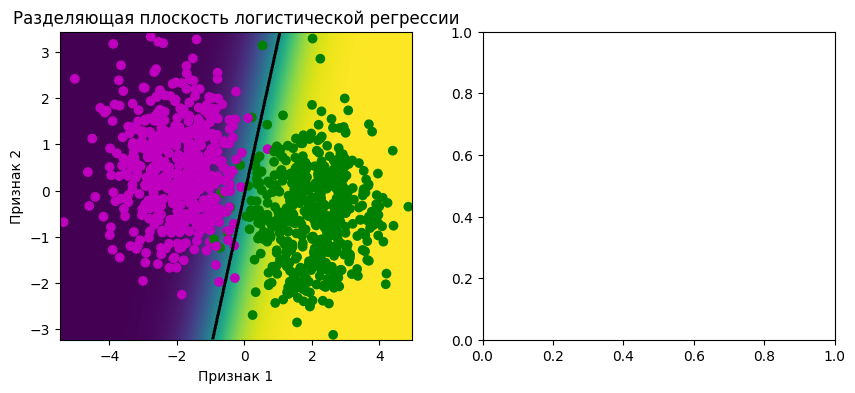

In [40]:
plot_clf_results(CLF_1, X, y)

In [ ]:
CLF_2 = MyLogisticRegression(max_iter=100, lr=0.1, C=0.003)

CLF_2.fit(X, y);

In [ ]:
plot_clf_results(CLF_2, X, y)

Два наблюдения:
1. Потери с сильной регуляризацией (низкой сложностью `C=0.003`) больше
2. Граница более размыта, модель предсказывает довольно близкие к $\frac{1}{2}$ вероятности – это значит, что значения ${\langle x, x\rangle}$ близки к нулю, то есть сам вектор $w$ близок к нулевому. Это также свидетельствует о том, что регуляризационный член играет слишком важную роль при оптимизации. Наименьший коэффициент регуляризации у первой модели. Её предсказания достаточно «уверенные» (цвета на графике сочные, то есть вероятности быстро приближаются к $0$ или $1$). Это может свидетельствовать о том, что числа ${\langle x, x\rangle}$ достаточно велики по модулю, то есть $||w||$ достаточно велик.

# <a id='toc4_'></a>[Приложение](#toc0_)

## <a id='toc4_1_'></a>["Распремление" поверхности весов из-за мультиколлинеарности признаков](#toc0_)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
X1 = np.array([1, 2, 3])
X2 = X1

y = X1 + X2
X = np.column_stack((X1, X2))

In [ ]:
points = []

for w1 in np.arange(-4, 7, 1):
    for w2 in np.arange(-4, 7, 1):
        w = [w1, w2]
        y_pred = X @ w
        mse = int(mean_squared_error(y, y_pred))
        points.append((w1, w2, mse))

w1_vals = [point[0] for point in points]
w2_vals = [point[1] for point in points]
mse_vals = [point[2] for point in points]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(w1_vals, w2_vals, mse_vals, c='r', marker='o')

ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('MSE')

plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
contour = plt.tricontourf(w1_vals, w2_vals, mse_vals, levels=30, cmap='viridis')
plt.colorbar(contour, label='MSE')

plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Контуры MSE в плоскости w1-w2')

plt.show()